In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Load an image
file_im = 'ProjectInDataScience2026_Exercises/02_Images/example_im.png'
file_mask = 'ProjectInDataScience2026_Exercises/02_Images/example_mask.png'

im = plt.imread(file_im)
mask = plt.imread(file_mask)
mask = mask > 0

We can display the image and mask real quick to see what we are working with.

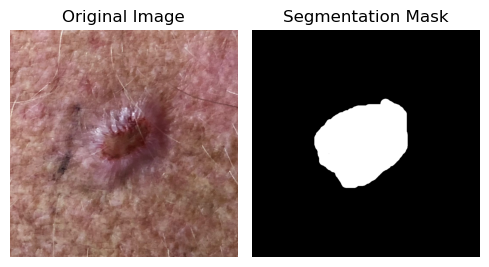

In [35]:
def display_images(im1, im2, title_1: str, title_2: str):
    # Display im and mask side by side
    fig, axes = plt.subplots(1, 2, figsize=(5, 3))
    # Display im1
    axes[0].imshow(im1, cmap='gray')
    axes[0].set_title(title_1)
    axes[0].axis('off')
    # Display im2
    axes[1].imshow(im2, cmap='gray')
    axes[1].set_title(title_2)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    return

display_images(im, mask, 'Original Image', 'Segmentation Mask')

# Assymetry metric

Spherical assymetry metric (Works as intended)

In [43]:
from skimage.measure import label, regionprops

#Contains information about shape of mask eg. center, area
props1 = regionprops(mask.astype(int))[0]

#Find the center of the mask
cy1, cx1 = props.centroid

#All angles in radians
angles1 = np.deg2rad(np.arange(360))

def radial_distance(mask, cx, cy, theta, max_radius=1000):
    """Measures how far the shape extendes in one direction.
    Theta is the angle(direction), max_radius is just a safety limit so we don't loop forever"""
    
    #Starts walking outward from the center
    for r in range(1, max_radius):
        x1 = int(cx1 + r *np.cos(theta))
        y1 = int(cy1 + r * np.sin(theta))

        #checks if we walked outside the image
        if x1 < 0 or x1 >= mask.shape[1] or y1 < 0 or y1 >= mask.shape[0]:
            return r
        
        #checks if we left the mask
        if mask[y1, x1] == 0:
            return r
    
    #in case we never hit the edge
    return max_radius


#measure all 360 directions
radii1 = [radial_distance(mask, cx1, cy1, th) for th in angles1]

#turn list into numpy array
radii1 = np.array(radii1)

#compute assymetry score by standard deviation divided by mean
assymetry_score1 = np.std(radii1) / np.mean(radii1)






#test on the example mask
print("Assymetry score:", assymetry_score1)


Assymetry score: 0.11202050541459681


Symmetric around any one axis (something goes wrong and itgives wayyyyyy too large numbers)

In [58]:
import numpy as np
from skimage.measure import regionprops

def reflect_points_across_axis(points, angle):
    """Reflects a set of (y, x) points across a linethrough the origin with an angle(in degrees)"""
    theta = np.deg2rad(angle)

    #Unit normal vector of the axis
    nx = np.cos(theta)
    ny = np.sin(theta)

    #Dot product of each point with the normal
    dot = points[:, 1] * nx + points[:, 0] * ny

    #Reflection formula: p' =p - 2*(p dot n)*n
    reflected_x = points[:, 1] - 2 * dot * nx
    reflected_y = points[:, 0] - 2 * dot * ny

    return np.vstack([reflected_y, reflected_x]).T



def axis_symmetry_score(mask, angle):
    """Compute symmetry score for a given axis"""
    H, W = mask.shape

    #Get coordinates of all foreground pixels
    ys, xs = np.where(mask > 0)
    pts = np.vstack([ys, xs]).T

    #Reflect them across the axis
    reflected = reflect_points_across_axis(pts, angle)

    #Round to nearest pixel
    reflected = np.rint(reflected).astype(int)

    #Count how many reflected points fall outside the mask
    bad = 0
    for y, x in reflected:
        if not (0 <= y < H and 0 <= x < W and mask[y,x] > 0):
            bad += 1
    
    return bad


def full_symmetry_score(mask):
    """Find best symmetry axis"""
    best = np.inf

    #Try 180 possible axes
    for angle in range(180):
        score = axis_symmetry_score(mask, angle)
        if score < best:
            best = score
        
    return best


def center_mask(mask):
    """Center mask before symmetry testing"""
    props = regionprops(mask.astype(int))[0]
    cy, cx = props.centroid

    H, W = mask.shape
    dy = H//2 - int(cy)
    dx = W//2 - int(cx)

    return np.roll(mask, shift=(dy, dx), axis=(0, 1))



shifted = center_mask(mask)
score = full_symmetry_score(shifted)

print("Asymmetry score:", score)




Asymmetry score: 14551
